<a href="https://colab.research.google.com/github/chaitanyatalakeri27-png/Data_Science_Lab/blob/main/Exp2_Backpropagation_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(
[[0. 1.]
 [2. 3.]], shape=(2, 2), dtype=float32)
[[0. 1.]
 [2. 3.]]
<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([1., 2.], dtype=float32)>
tf.Tensor(
[[1.]
 [2.]], shape=(2, 1), dtype=float32)
tf.Tensor(
[[2.]
 [8.]], shape=(2, 1), dtype=float32)


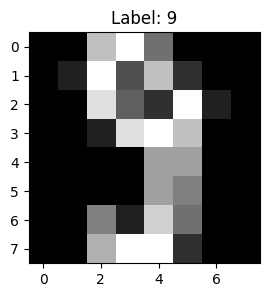

Epoch 1, Loss: 2.4869, Accuracy: 0.0696
Epoch 2, Loss: 2.1707, Accuracy: 0.2081
Epoch 3, Loss: 1.9018, Accuracy: 0.4774
Epoch 4, Loss: 1.6651, Accuracy: 0.6562
Epoch 5, Loss: 1.4488, Accuracy: 0.7613
Epoch 6, Loss: 1.2482, Accuracy: 0.8100
Epoch 7, Loss: 1.0638, Accuracy: 0.8365
Epoch 8, Loss: 0.8985, Accuracy: 0.8643
Epoch 9, Loss: 0.7552, Accuracy: 0.8803
Epoch 10, Loss: 0.6342, Accuracy: 0.8935
Epoch 11, Loss: 0.5336, Accuracy: 0.9033
Epoch 12, Loss: 0.4506, Accuracy: 0.9158
Epoch 13, Loss: 0.3822, Accuracy: 0.9255
Epoch 14, Loss: 0.3264, Accuracy: 0.9304
Epoch 15, Loss: 0.2816, Accuracy: 0.9353
Epoch 16, Loss: 0.2456, Accuracy: 0.9408
Epoch 17, Loss: 0.2163, Accuracy: 0.9436
Epoch 18, Loss: 0.1914, Accuracy: 0.9506
Epoch 19, Loss: 0.1700, Accuracy: 0.9582
Epoch 20, Loss: 0.1516, Accuracy: 0.9645
Epoch 21, Loss: 0.1361, Accuracy: 0.9673
Epoch 22, Loss: 0.1230, Accuracy: 0.9694
Epoch 23, Loss: 0.1117, Accuracy: 0.9715
Epoch 24, Loss: 0.1019, Accuracy: 0.9743
Epoch 25, Loss: 0.0931, A

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# TensorFlow Constants and Variables

a = tf.constant(3)
print(a)

b = tf.constant(2)
c = a + b
print(c)

# Matrix Operations
A = tf.constant([[0, 1], [2, 3]], dtype=tf.float32)
print(A)

print(A.numpy())

b = tf.Variable([1, 2], dtype=tf.float32)
print(b)

reshaped_b = tf.reshape(b, (-1, 1))
print(reshaped_b)

matmul_result = tf.matmul(A, reshaped_b)
print(matmul_result)

# Load Dataset

digits = load_digits()

X = digits.data
y = digits.target

# Show Sample Image - Changed index to 125 to show a DIFFERENT image
sample_idx = 125
plt.figure(figsize=(3,3))
plt.imshow(digits.images[sample_idx], cmap='gray')
plt.title(f"Label: {digits.target[sample_idx]}")
plt.show()

# Train Test Split - Changed random_state to 123 for different data mixing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One Hot Encoding
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Convert to TensorFlow tensors
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
Y_train = tf.convert_to_tensor(Y_train, dtype=tf.float32)
Y_test = tf.convert_to_tensor(Y_test, dtype=tf.float32)

# Define Variables for Neural Network
initializer = tf.initializers.GlorotUniform()

# Changed shape to 150
W1 = tf.Variable(initializer(shape=(64, 150)))
b1 = tf.Variable(tf.zeros([150]))

# Changed shape to (150, 75)
W2 = tf.Variable(initializer(shape=(150, 75)))
b2 = tf.Variable(tf.zeros([75]))

# Changed shape to (75, 10)
W3 = tf.Variable(initializer(shape=(75, 10)))
b3 = tf.Variable(tf.zeros([10]))

# Forward Pass Function

def neural_network(x):
    z1 = tf.matmul(x, W1) + b1
    a1 = tf.nn.relu(z1)

    z2 = tf.matmul(a1, W2) + b2
    a2 = tf.nn.relu(z2)

    z3 = tf.matmul(a2, W3) + b3

    return z3

# Loss Function

def compute_loss(logits, labels):
    loss = tf.reduce_mean(
        tf.nn.softmax_cross_entropy_with_logits(
            labels=labels,
            logits=logits
        )
    )
    return loss

# Optimizer - Changed learning rate to 0.003
optimizer = tf.optimizers.Adam(learning_rate=0.003)

# Training Loop
epochs = 35 # Changed to 35 epochs

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        logits = neural_network(X_train)
        loss = compute_loss(logits, Y_train)

    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2, W3, b3]
    )

    optimizer.apply_gradients(
        zip(gradients, [W1, b1, W2, b2, W3, b3])
    )

    predictions = tf.argmax(logits, axis=1)
    actual = tf.argmax(Y_train, axis=1)

    accuracy = tf.reduce_mean(
        tf.cast(predictions == actual, tf.float32)
    )

    print(
        f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}, Accuracy: {accuracy.numpy():.4f}"
    )

# Testing

test_logits = neural_network(X_test)

test_predictions = tf.argmax(test_logits, axis=1)
test_actual = tf.argmax(Y_test, axis=1)

test_accuracy = tf.reduce_mean(
    tf.cast(test_predictions == test_actual, tf.float32)
)

print("\nTest Accuracy:", test_accuracy.numpy())